In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Patch
from odc.stac import configure_s3_access, load
from pystac_client import Client

configure_s3_access(aws_unsigned=True)

In [18]:
catalog = "https://stac.staging.digitalearthpacific.io"
client = Client.open(catalog)

In [28]:
fiji_bbox = [177.2, -18.4, 178.9, -17.2]
datetime = "2017"

items = list(client.search(collections=["dep_s2s1_mrd"], bbox=fiji_bbox, datetime=datetime).items())

print(f"Found {len(items)} items")

Found 6 items


In [29]:
data = load(items, bbox=fiji_bbox, resolution=100, chunks={})
data

<xarray.Dataset> Size: 21MB
Dimensions:      (y: 1396, x: 1894, time: 1)
Coordinates:
  * y            (y) float64 11kB -1.931e+06 -1.932e+06 ... -2.071e+06
  * x            (x) float64 15kB 3.028e+06 3.028e+06 ... 3.217e+06 3.217e+06
  * time         (time) datetime64[ns] 8B 2017-01-01
    spatial_ref  int32 4B 3832
Data variables:
    class        (time, y, x) float32 11MB dask.array<chunksize=(1, 1396, 1894), meta=np.ndarray>
    proba        (time, y, x) float32 11MB dask.array<chunksize=(1, 1396, 1894), meta=np.ndarray>

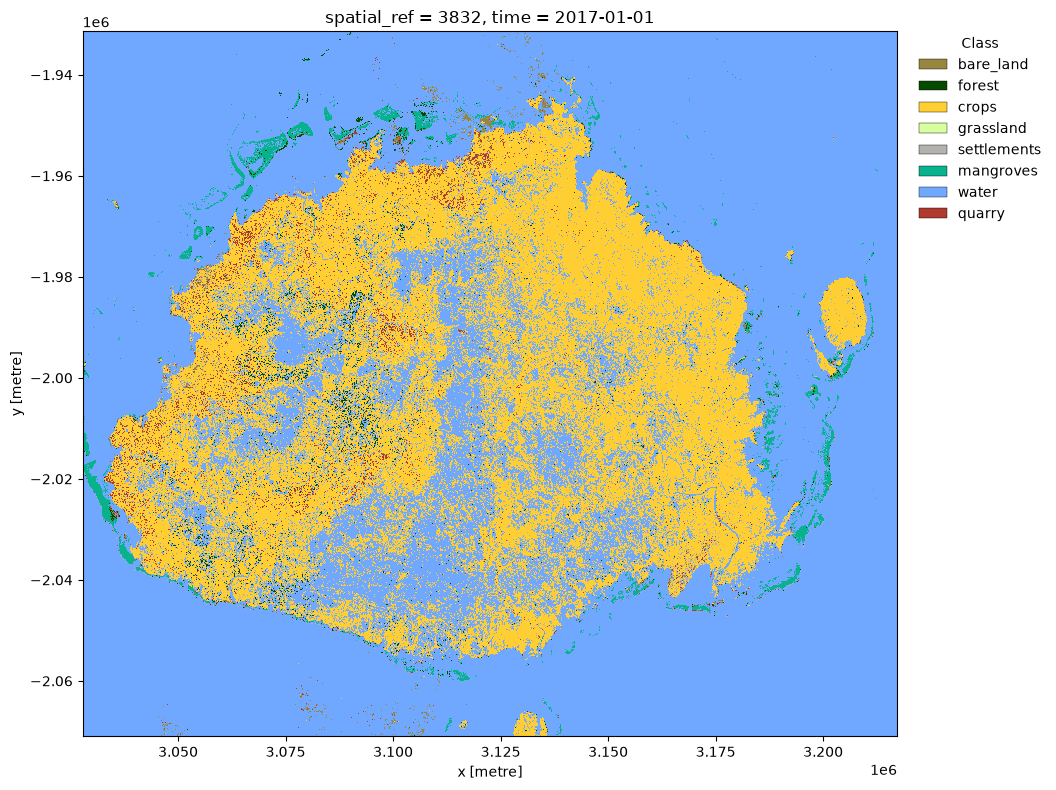

In [30]:
classes = [
    [1, "bare_land", "#968640"],
    [2, "forest", "#064a00"],
    [3, "crops", "#ffce33"],
    [4, "grassland", "#d7ffa0"],
    [5, "settlements", "#b3b2ae"],
    [6, "mangroves", "#07b28d"],
    [7, "water", "#71a8ff"],
    [8, "quarry", "#b03a2e"],
]

values_list = [c[0] for c in classes]
color_list = [c[2] for c in classes]
label_list = [c[1] for c in classes]

c_map = colors.ListedColormap(color_list)
bounds = values_list + [9]
norm = colors.BoundaryNorm(bounds, c_map.N)

p = data["class"].isel(time=0).plot.imshow(
    cmap=c_map, norm=norm, add_colorbar=False, size=8
)
ax = p.axes  # grab the axes xarray created, sized to match the data's aspect ratio

patches = [
    Patch(facecolor=color, edgecolor="black", linewidth=0.3, label=label)
    for label, color in zip(label_list, color_list)
]
ax.legend(
    handles=patches,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False,
    title="Class",
)

plt.tight_layout()
plt.show()